In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings 
warnings .filterwarnings("ignore")

In [27]:
df = pd.read_csv("players_20.csv")

In [28]:
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [16]:
df.isna().sum()

sofifa_id        0
player_url       0
short_name       0
long_name        0
age              0
              ... 
lb            2036
lcb           2036
cb            2036
rcb           2036
rb            2036
Length: 104, dtype: int64

In [17]:
df.shape

(18278, 104)

In [30]:
df.drop_duplicates(inplace=True)
df = df.dropna(thresh=df.shape[1]*0.7)

In [31]:
top_countries = df['nationality'].value_counts().head(10)
top_countries

nationality
England        1497
Germany        1055
Spain           922
France          881
Argentina       796
Brazil          751
Italy           630
Colombia        545
Japan           398
Netherlands     364
Name: count, dtype: int64

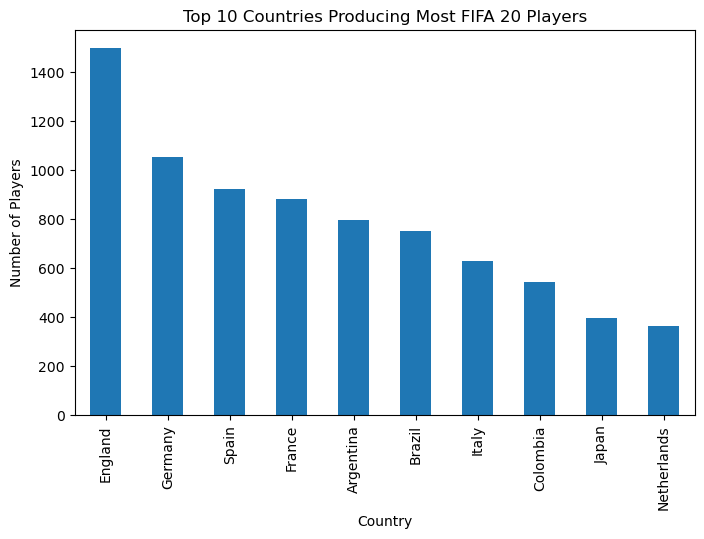

In [32]:
plt.figure(figsize=(8,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Most FIFA 20 Players")
plt.xlabel("Country")
plt.ylabel("Number of Players")
plt.show()

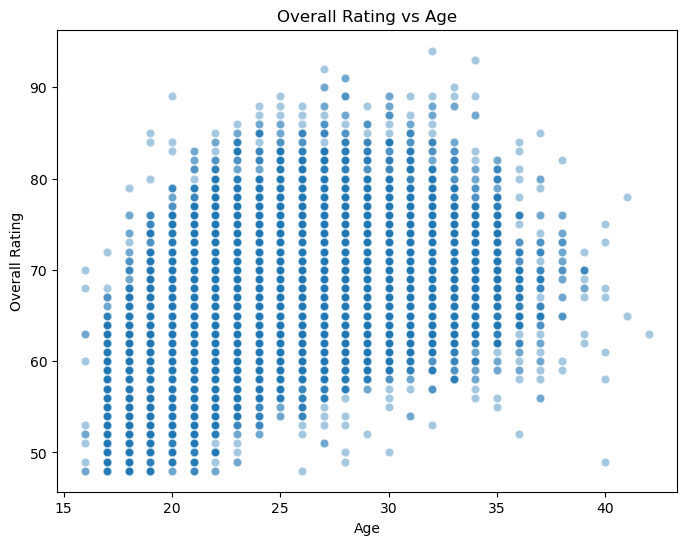

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='overall', data=df, alpha=0.4)
plt.title("Overall Rating vs Age")
plt.xlabel("Age")
plt.ylabel("Overall Rating")
plt.show()

In [34]:
offensive_positions = df[df['player_positions'].str.contains('ST|RW|LW', na=False)]
def offensive_role(pos):
    if 'ST' in pos:
        return 'Striker'
    elif 'RW' in pos:
        return 'Right Winger'
    elif 'LW' in pos:
        return 'Left Winger'
    else:
        return 'Other'

offensive_positions['Role'] = offensive_positions['player_positions'].apply(offensive_role)
offensive_positions.groupby('Role')['wage_eur'].mean()

Role
Left Winger     13157.817109
Right Winger    12758.799172
Striker         10612.288786
Name: wage_eur, dtype: float64

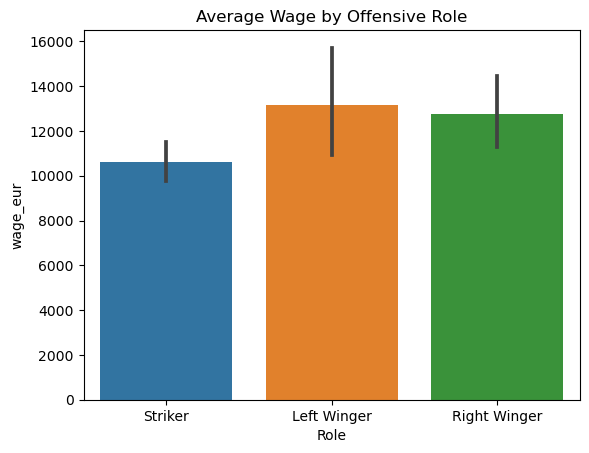

In [35]:
sns.barplot(x='Role', y='wage_eur', data=offensive_positions)
plt.title("Average Wage by Offensive Role")
plt.show()

In [37]:
features = ['pace','shooting','passing','dribbling','defending','physic']
cluster_data = df[features].dropna()

In [38]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

In [41]:
sil_scores = []
for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    sil_scores.append(score)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.281
k=3, silhouette score=0.265
k=4, silhouette score=0.241
k=5, silhouette score=0.217
k=6, silhouette score=0.222
k=7, silhouette score=0.223
k=8, silhouette score=0.207
k=9, silhouette score=0.199


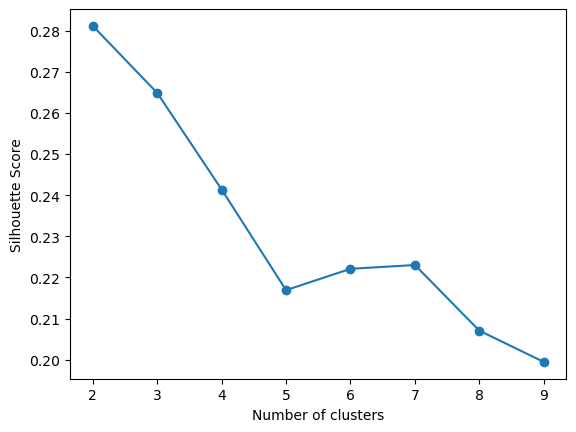

In [43]:
plt.plot(range(2,10), sil_scores, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [44]:
kmeans = KMeans(n_clusters=4, random_state=42)
df.loc[cluster_data.index, 'Cluster'] = kmeans.fit_predict(scaled_data)

In [45]:
df.groupby('Cluster')[features].mean()

,pace,shooting,passing,dribbling,defending,physic
Cluster,,,,,,
0.0,67.560962,53.871785,63.530435,66.125069,64.854764,70.628307
1.0,58.042363,33.607860,45.764493,48.740245,61.912765,67.926143
2.0,76.516773,67.297571,64.789184,72.521400,38.768652,64.007519
3.0,69.000264,54.062780,52.219731,61.348721,34.446584,54.582960


In [52]:
print("KMeans Silhouette:", silhouette_score(scaled_data, kmeans.labels_))

KMeans Silhouette: 0.24136356895305172
